# PDP data와 sales 연관성/EDA

In [113]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [98]:
df = pd.read_csv('0618_amz_pdp_price_sales_gv_top80_data.csv')
print(df)

       crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
0      2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
1      2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
2      2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
3      2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
4      2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...           ...         ...     ...            ...         ...         ...   
50054  2025-06-13  B0CKYYMG6F     4.4        78216.0       399.0         4.0   
50055  2025-06-13  B0CSJTBM1L     4.4         9849.0       693.0         7.0   
50056  2025-06-13  B0CSJX57TM     4.4         5200.0      3714.0        18.0   
50057  2025-06-13  B089ZYJKBK     4.5         2106.0     40615.0       183.0   
50058  2025-06-13  B0CKYZJY5T     4.2        16413.0      3420.0        16.0   

       salesrank3  bw_price  revenue  u

In [100]:
# 날짜 컬럼이 문자열인 경우 datetime으로 변환
df['crawl_date'] = pd.to_datetime(df['crawl_date'])

In [108]:
print(df.dtypes)

crawl_date       datetime64[ns]
asin                     object
rating                  float64
ratings_total           float64
salesrank1              float64
salesrank2              float64
salesrank3              float64
bw_price                float64
revenue                 float64
units                   float64
gv                      float64
dtype: object


In [110]:
print(df['revenue'].mean())

5355.041169420085


### 1. 각 변수의 히스토그램, 사분위 그리기

In [47]:
# 연속형 변수 리스트
continuous_cols = ['rating', 'ratings_total', 'salesrank2', 'bw_price', 'revenue', 'units', 'gv']

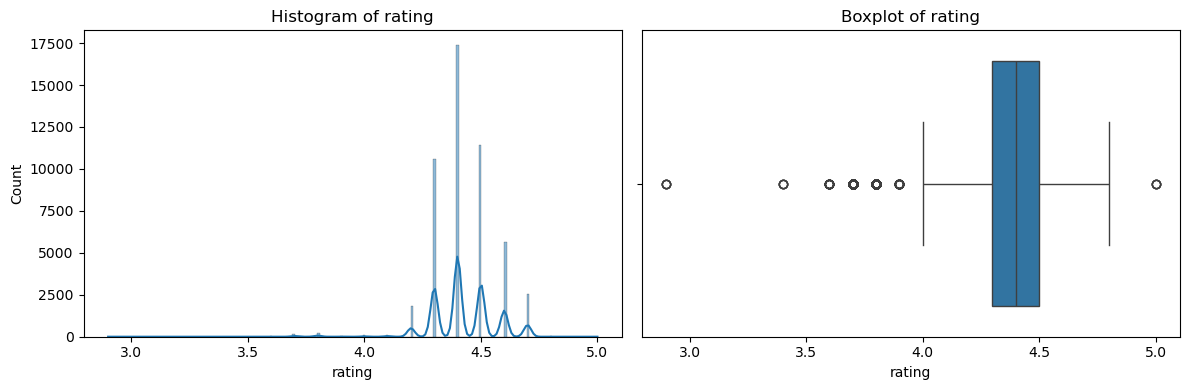

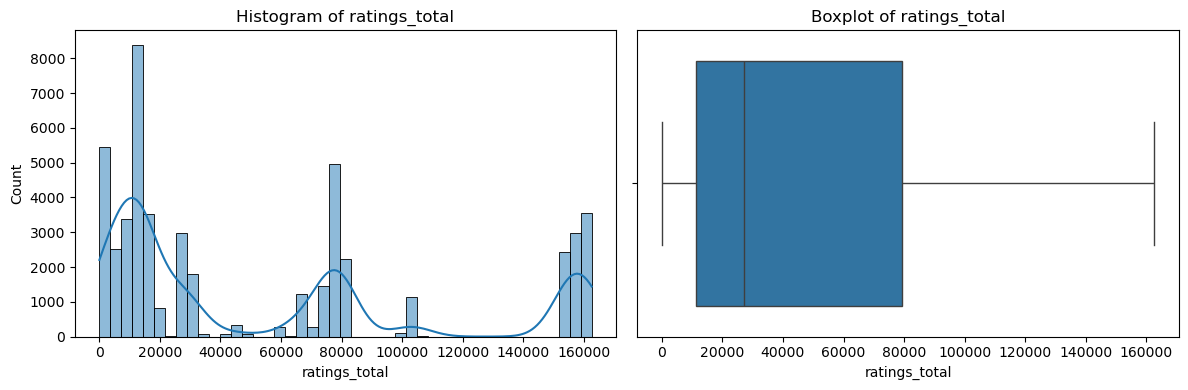

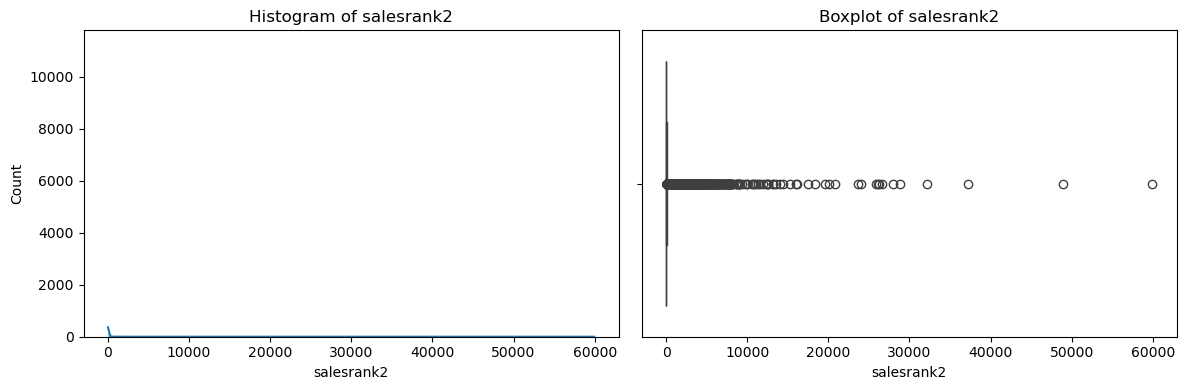

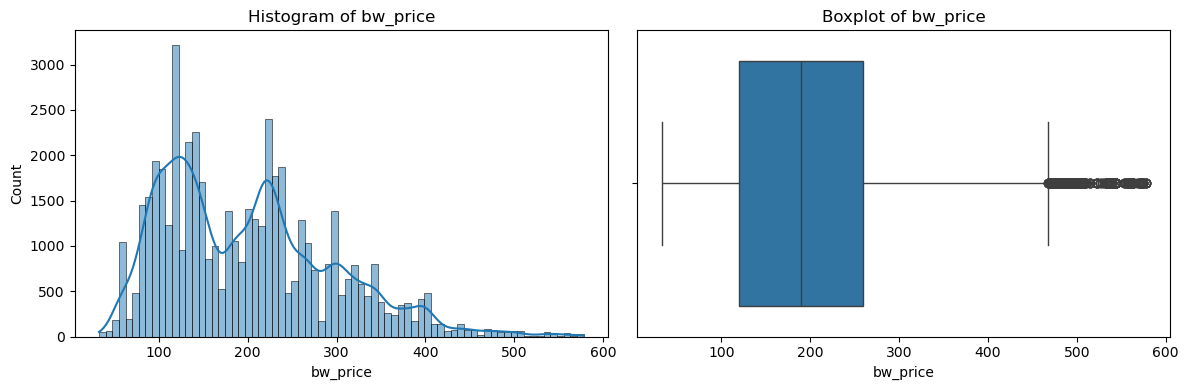

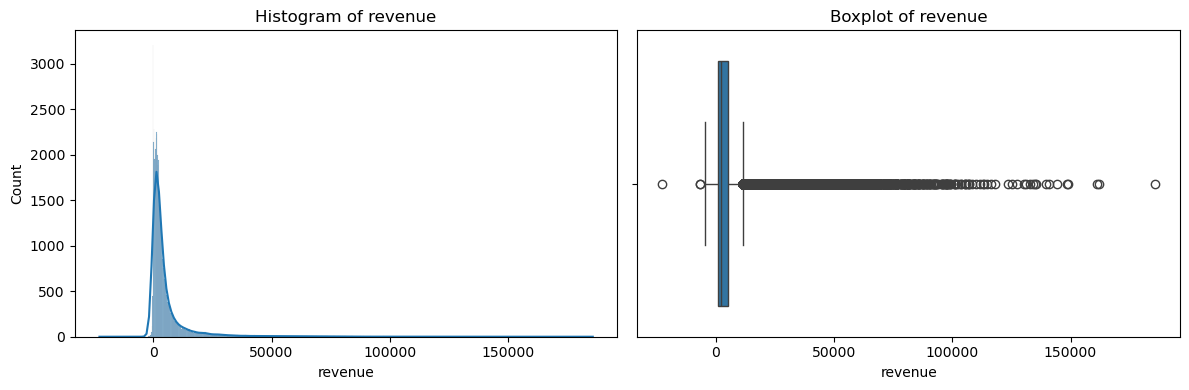

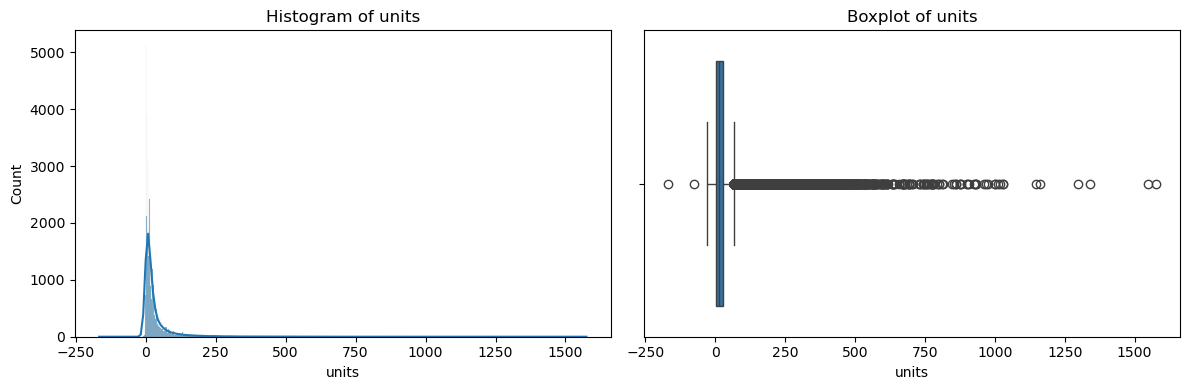

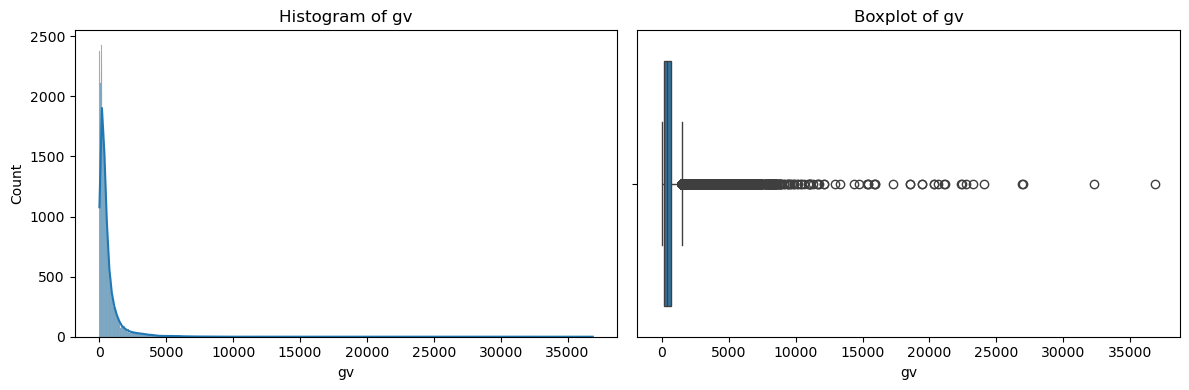

In [49]:
for col in continuous_cols:
    # units, gv 컬럼만 로그 변환
   # if col in ['units', 'gv']:
    #df[col] = np.log1p(df[col])  # log1p(x) = log(1+x), 0값 안전하게 처리
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 히스토그램
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {col}')
    
    # 박스플롯(사분위 그래프)
    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

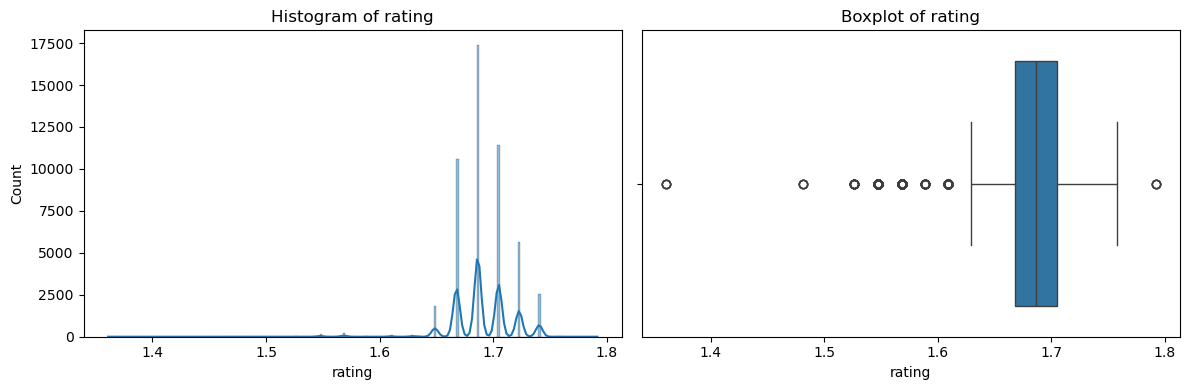

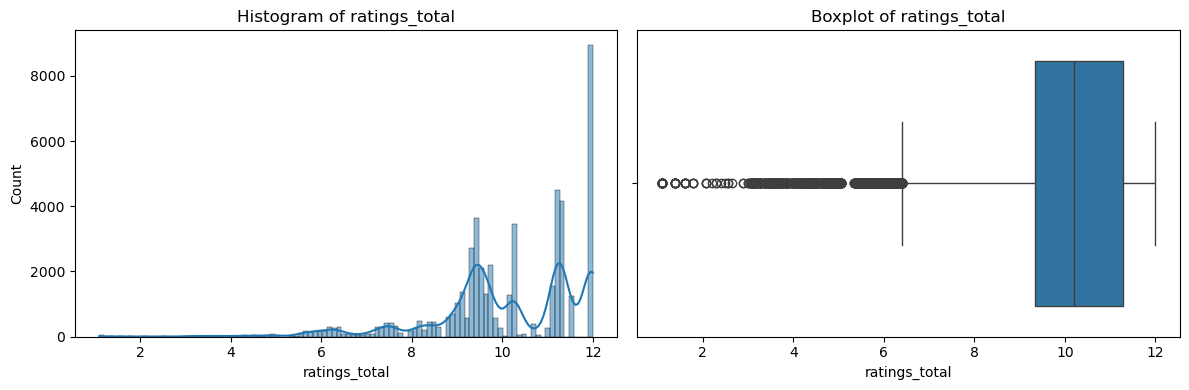

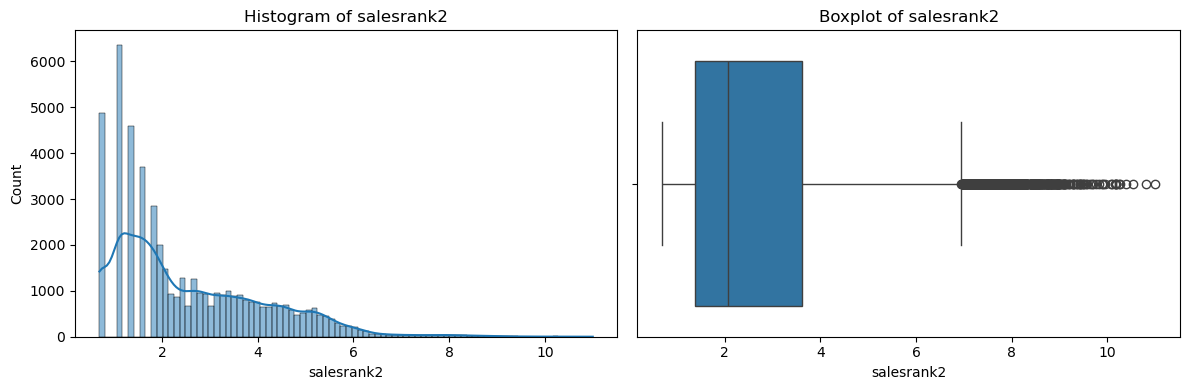

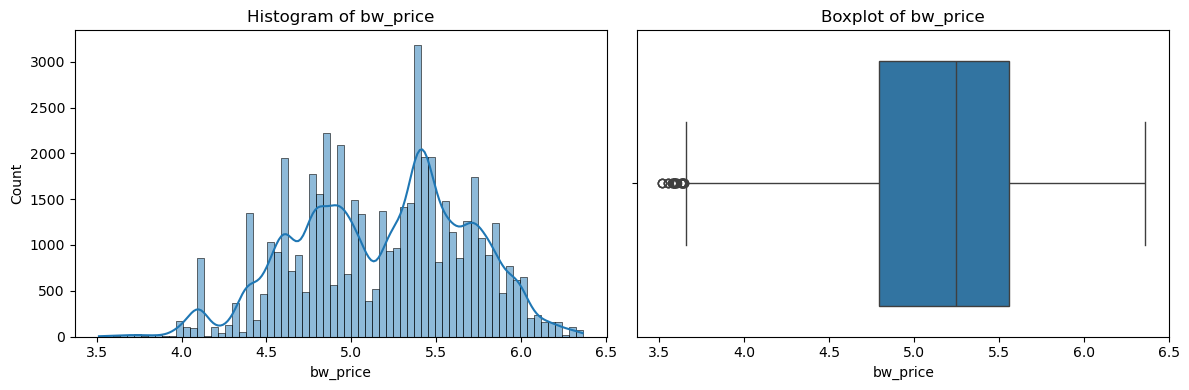

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


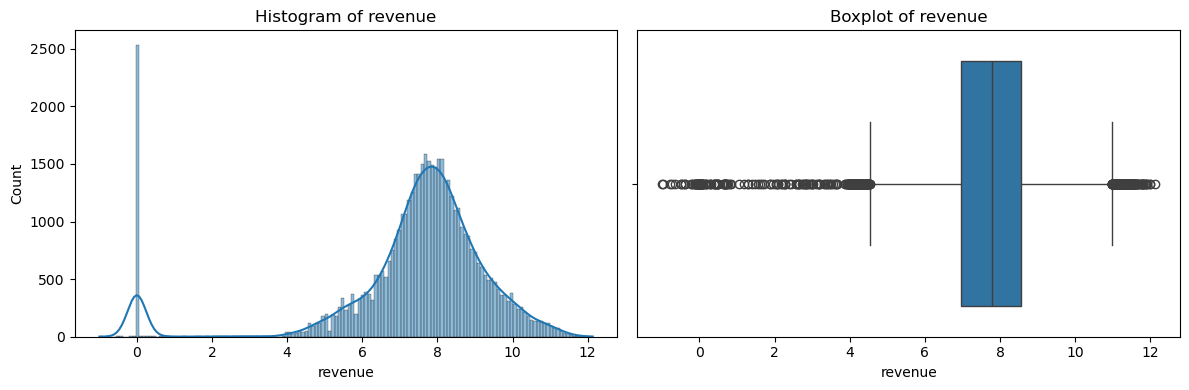

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


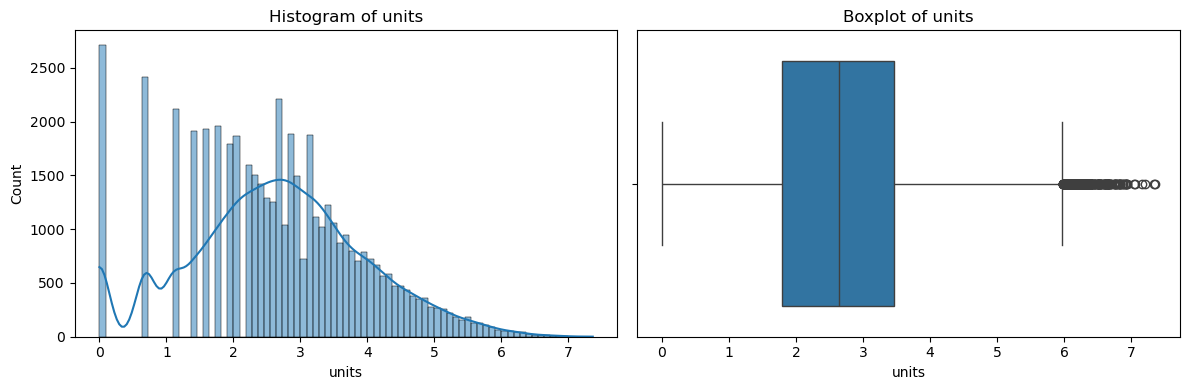

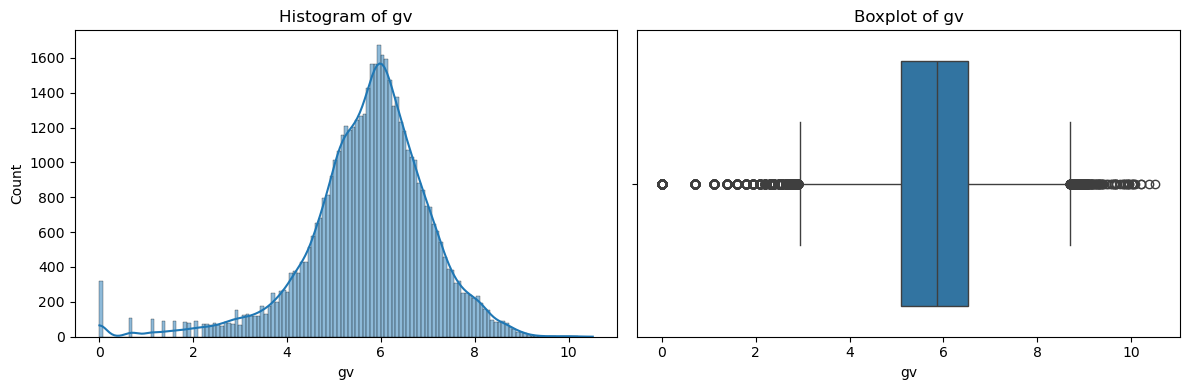

In [51]:
for col in continuous_cols:
    # units, gv 컬럼만 로그 변환
   # if col in ['units', 'gv']:
    df[col] = np.log1p(df[col])  # log1p(x) = log(1+x), 0값 안전하게 처리
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 히스토그램
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {col}')
    
    # 박스플롯(사분위 그래프)
    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

### 2. 상관계수 히트맵 그리기

In [84]:
# Data Loading
df = pd.read_csv('0618_amz_pdp_price_sales_gv_top80_data.csv')

In [86]:
# 날짜 컬럼이 문자열인 경우 datetime으로 변환
df['crawl_date'] = pd.to_datetime(df['crawl_date'])
print(df)

      crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
0     2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
1     2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
2     2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
3     2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
4     2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...          ...         ...     ...            ...         ...         ...   
50054 2025-06-13  B0CKYYMG6F     4.4        78216.0       399.0         4.0   
50055 2025-06-13  B0CSJTBM1L     4.4         9849.0       693.0         7.0   
50056 2025-06-13  B0CSJX57TM     4.4         5200.0      3714.0        18.0   
50057 2025-06-13  B089ZYJKBK     4.5         2106.0     40615.0       183.0   
50058 2025-06-13  B0CKYZJY5T     4.2        16413.0      3420.0        16.0   

       salesrank3  bw_price  revenue  units     gv 

In [88]:
# gv와 units 합계
total_gv = df['gv'].sum()
total_units = df['units'].sum()

# 비율 계산
ratio = total_units / total_gv * 100
print(ratio)

5.113399888658387


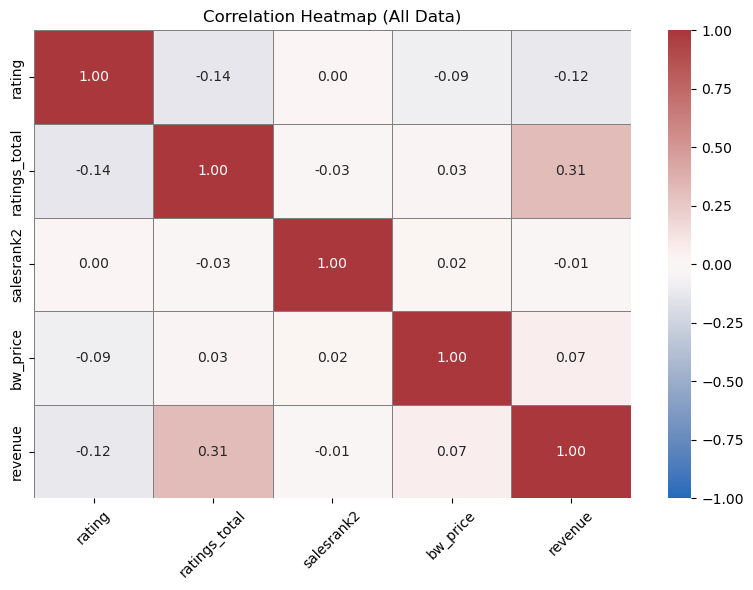

In [92]:
# 분석할 컬럼 선택
cols = ['rating', 'ratings_total', 'salesrank2', 'bw_price', 'revenue']

# 전체 데이터의 상관계수 행렬 계산
corr = df[cols].corr()

# Heatmap 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='vlag',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation Heatmap (All Data)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

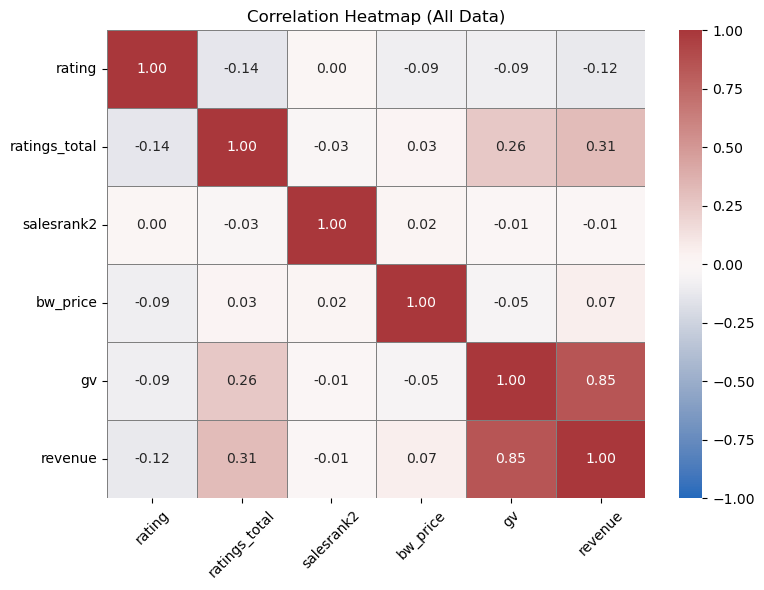

In [94]:
# 분석할 컬럼 선택
cols = ['rating', 'ratings_total', 'salesrank2', 'bw_price', 'gv', 'revenue']

# 전체 데이터의 상관계수 행렬 계산
corr = df[cols].corr()

# Heatmap 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='vlag',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation Heatmap (All Data)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. 산점도 그리기

In [70]:
# Data Loading
df = pd.read_csv('0618_amz_pdp_price_sales_gv_top80_data.csv')

In [78]:
# 매출 합 기준 asin top 5 추출
top5_asin = df.groupby('asin')['revenue'].sum().nlargest(5).index.tolist()

In [80]:
# 분석 컬럼 지정
x_cols = ['rating', 'ratings_total', 'salesrank2', 'bw_price', 'gv']
y_col = 'revenue'

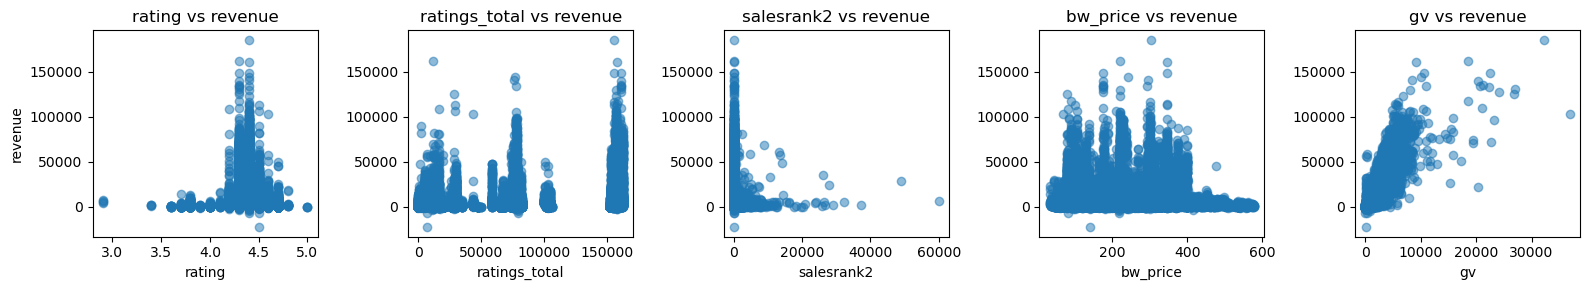

In [76]:
# 산점도 그리기
plt.figure(figsize=(16, 3))
for i, x in enumerate(x_cols):
    plt.subplot(1, len(x_cols), i+1)
    plt.scatter(df[x], df[y_col], alpha=0.5)
    plt.xlabel(x)
    plt.ylabel(y_col if i == 0 else '')
    plt.title(f"{x} vs {y_col}")
plt.tight_layout()
plt.show()

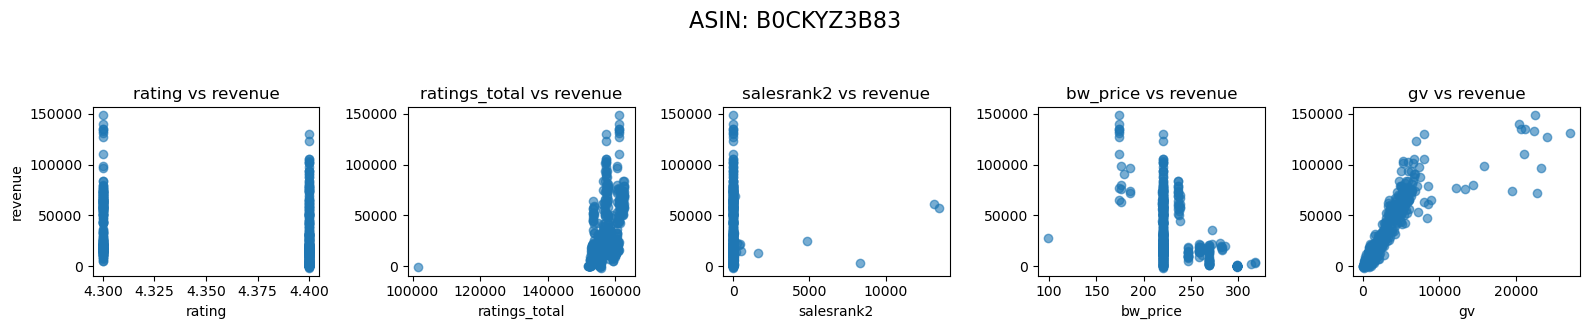

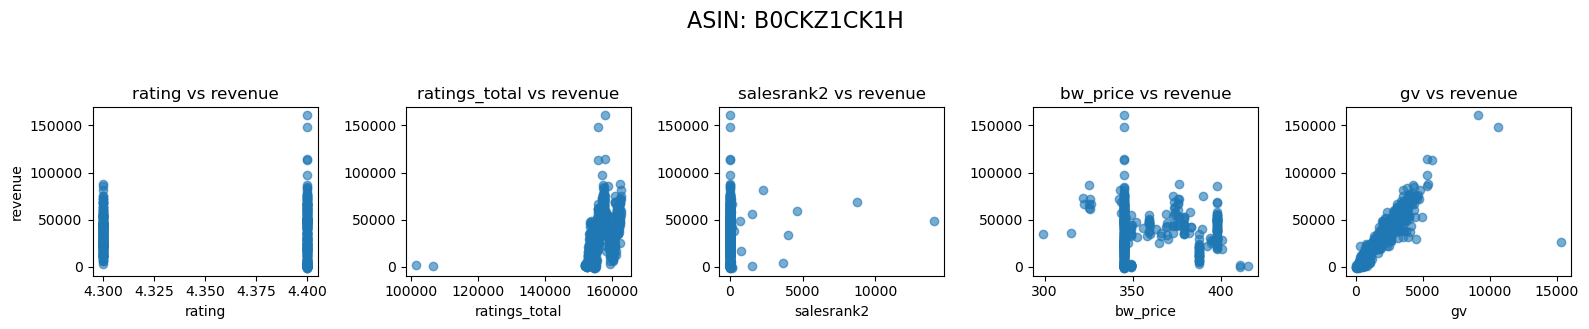

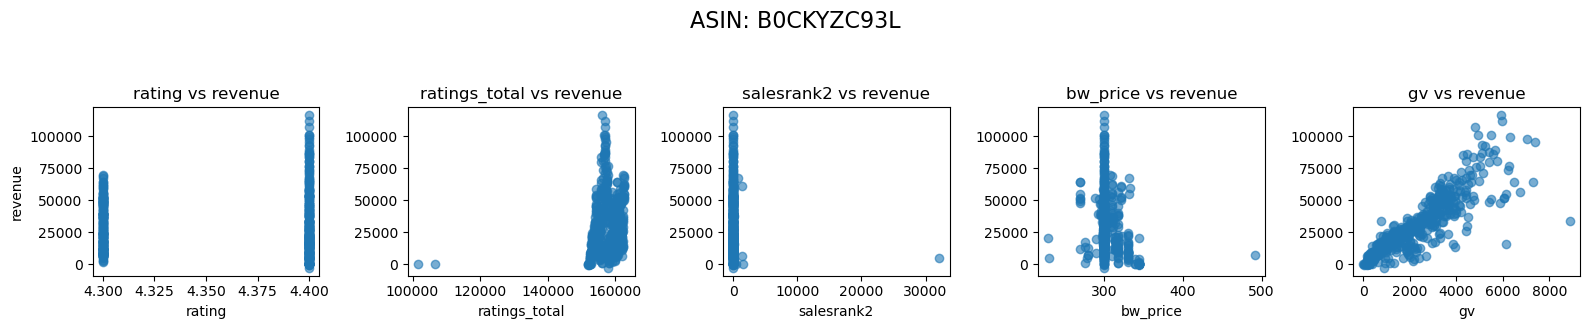

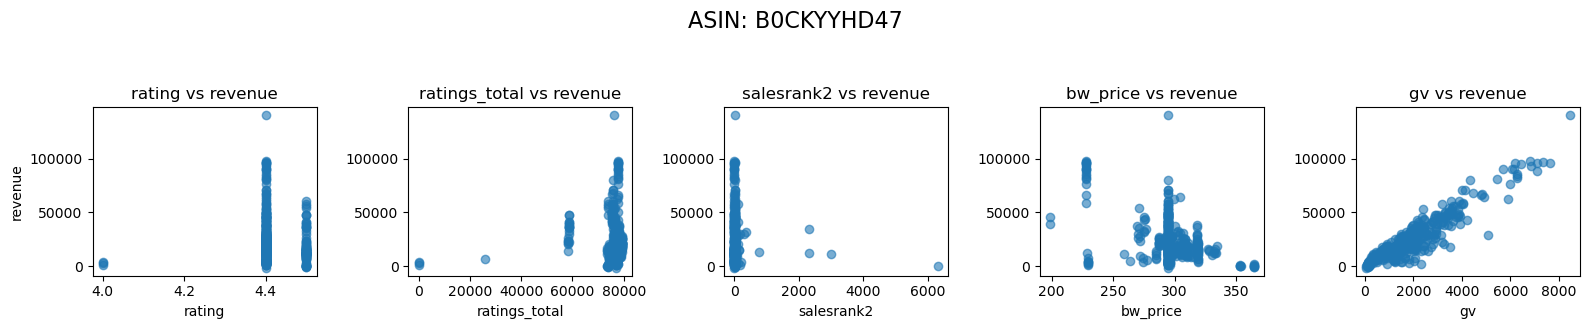

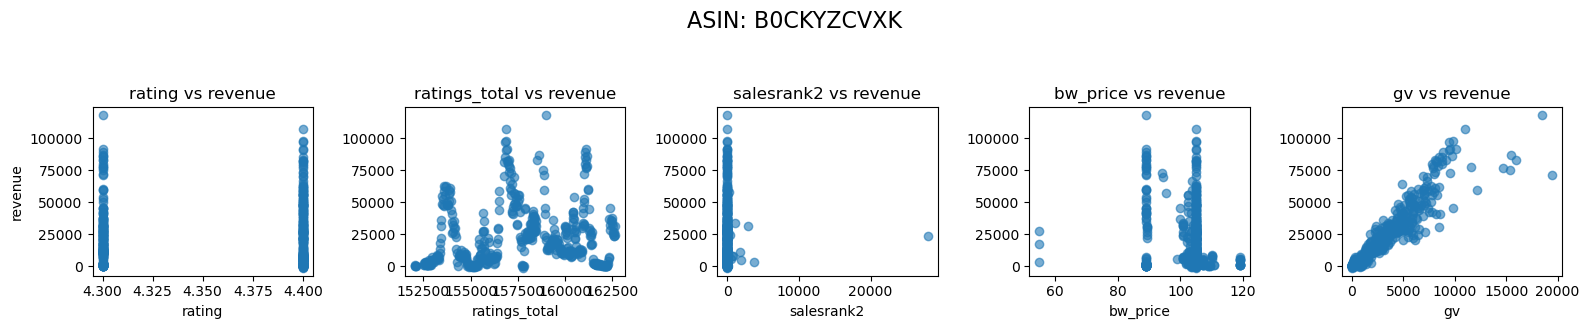

In [82]:
for asin in top5_asin:
    df_one = df[df['asin'] == asin][x_cols + [y_col]].dropna()
    plt.figure(figsize=(16, 3))
    for i, x in enumerate(x_cols):
        plt.subplot(1, len(x_cols), i+1)
        plt.scatter(df_one[x], df_one[y_col], alpha=0.6)
        plt.xlabel(x)
        plt.ylabel(y_col if i == 0 else '')
        plt.title(f"{x} vs {y_col}")
    plt.suptitle(f"ASIN: {asin}", fontsize=16, y=1.08)
    plt.tight_layout()
    plt.show()

### 4. 모델링하기

In [139]:
# 1. 데이터 불러오기 및 전처리 (이미 하셨으면 생략)
df = pd.read_csv('0618_amz_pdp_price_sales_gv_top80_data.csv')

In [117]:
X_cols = ['rating', 'ratings_total', 'salesrank2', 'bw_price', 'gv']
y_col = 'revenue'
df_model = df[X_cols + [y_col]].dropna()
X = df_model[X_cols]
y = df_model[y_col]

In [119]:
# 2. RandomForest 모델 학습 (이미 있으시면 생략)
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

RandomForestRegressor(max_depth=5, random_state=42)

In [120]:
# 3. 변수 중요도 추출
importances = rf.feature_importances_

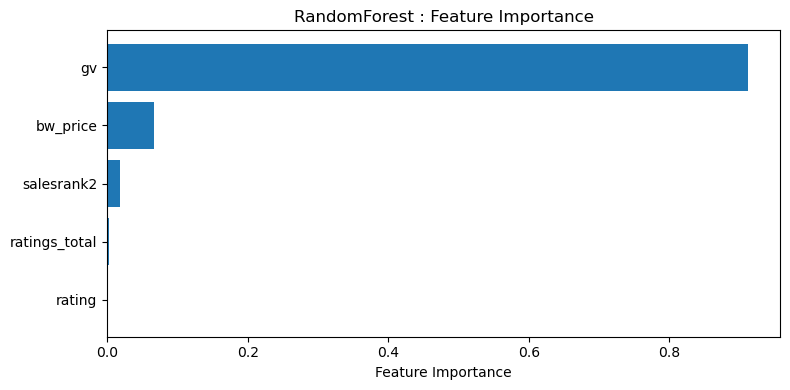

In [127]:
# 4. 시각화
plt.figure(figsize=(8,4))
plt.barh(X_cols, importances)
plt.xlabel('Feature Importance')
plt.title('RandomForest : Feature Importance')
plt.tight_layout()
plt.show()

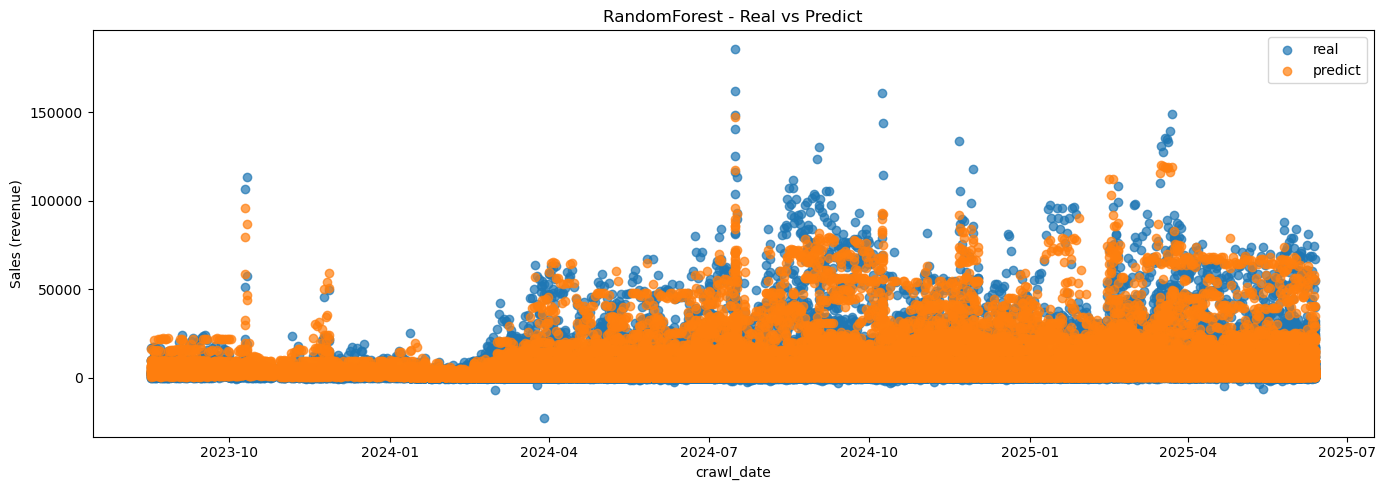

In [137]:
# crawl_date를 날짜형으로 변환
df_model['crawl_date'] = pd.to_datetime(df.loc[df_model.index, 'crawl_date'])

# 예측값 생성
y_pred = rf.predict(X)

# crawl_date 기준으로 정렬
sort_idx = np.argsort(df_model['crawl_date'])
dates_sorted = df_model['crawl_date'].iloc[sort_idx]
y_true_sorted = y.values[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(14,5))
plt.scatter(dates_sorted, y_true_sorted, label='real', alpha=0.7)
plt.scatter(dates_sorted, y_pred_sorted, label='predict', alpha=0.7)
#plt.plot(dates_sorted, y_pred_sorted, label='예측값', color='red', linewidth=2)
plt.xlabel('crawl_date')
plt.ylabel('Sales (revenue)')
plt.title('RandomForest - Real vs Predict')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu

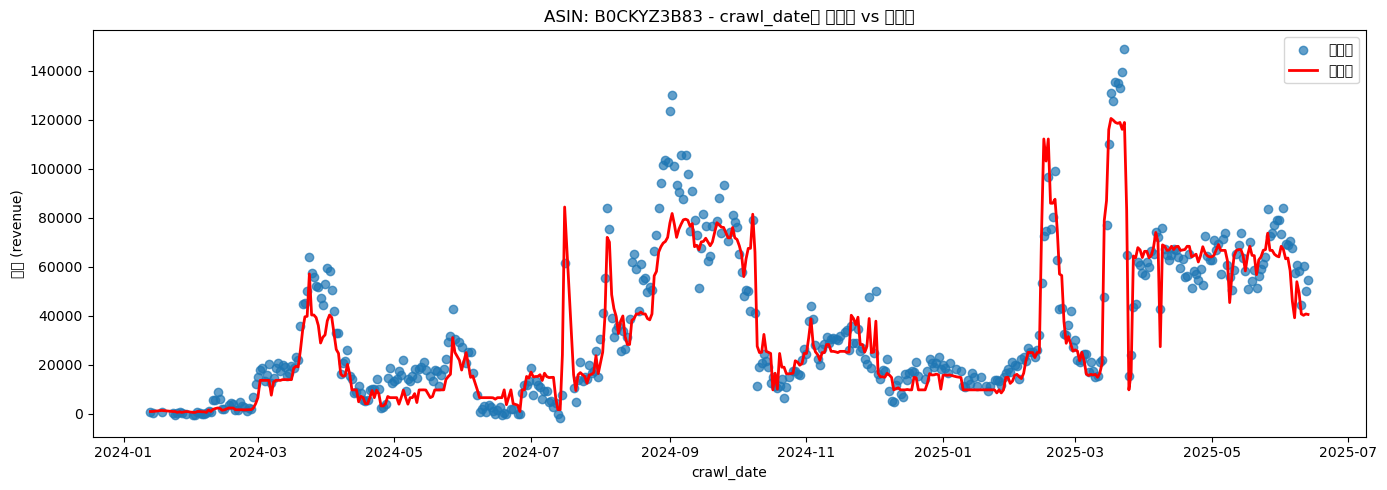

C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu

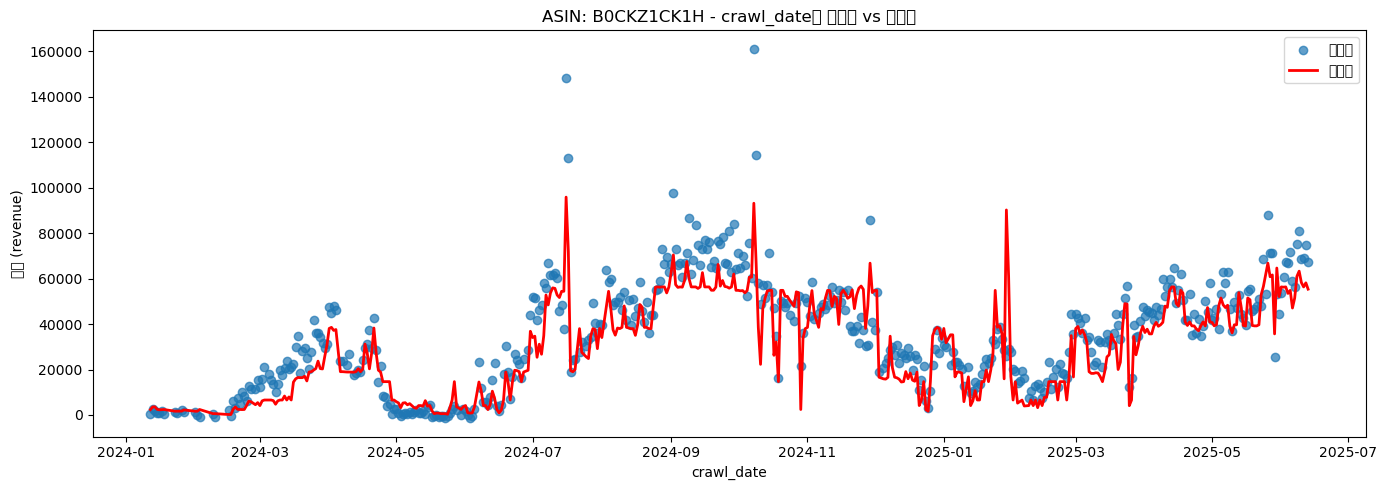

C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu

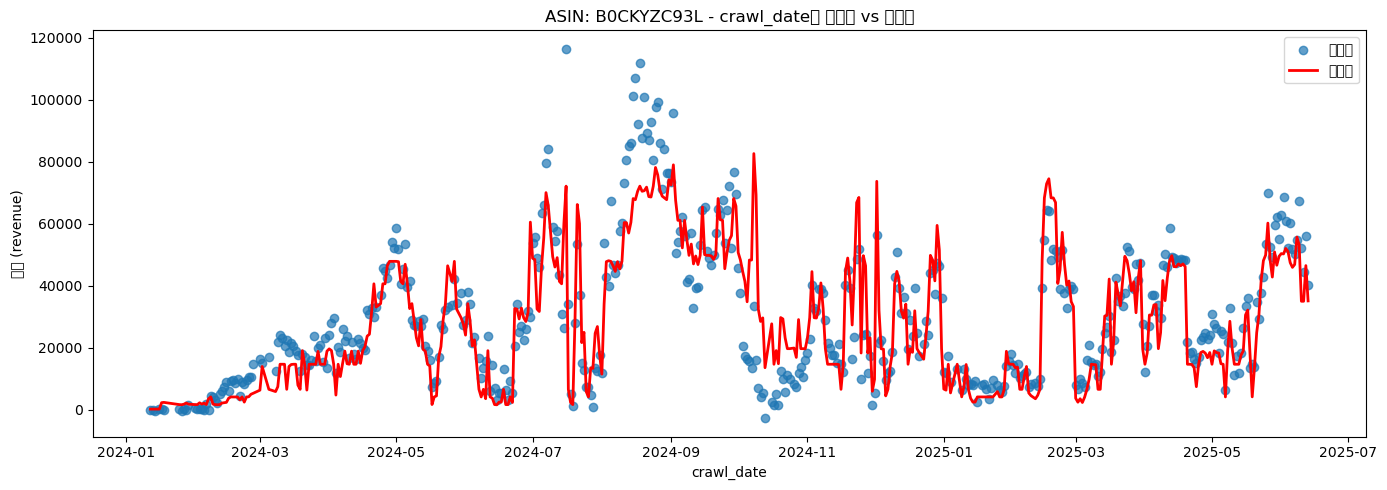

C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu

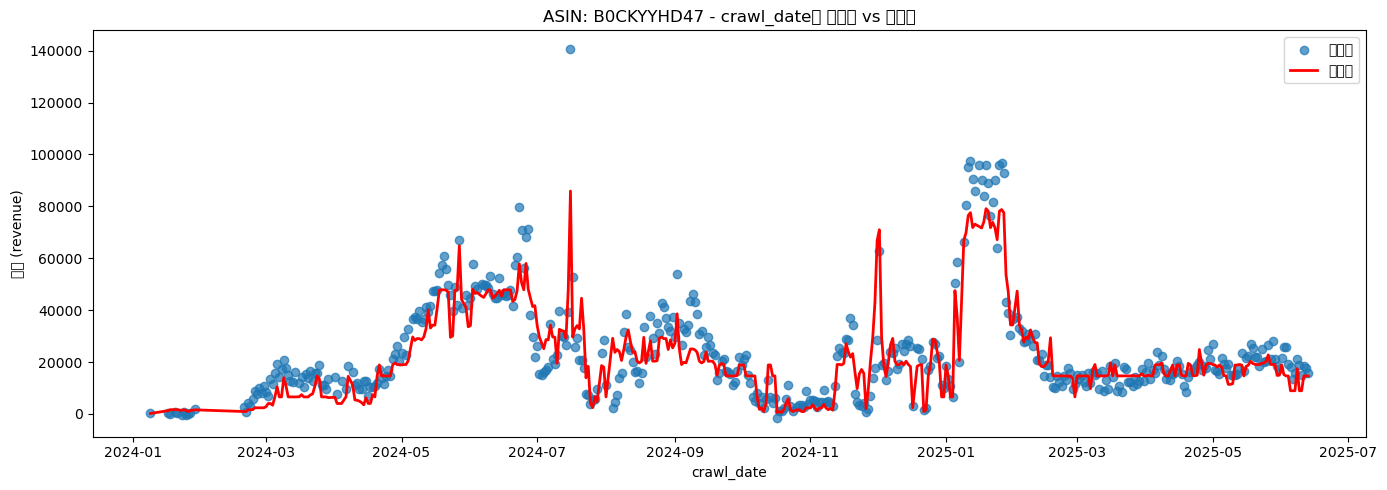

C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\최태욱\AppData\Local\Temp\ipykernel_10220\847680889.py:25: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu

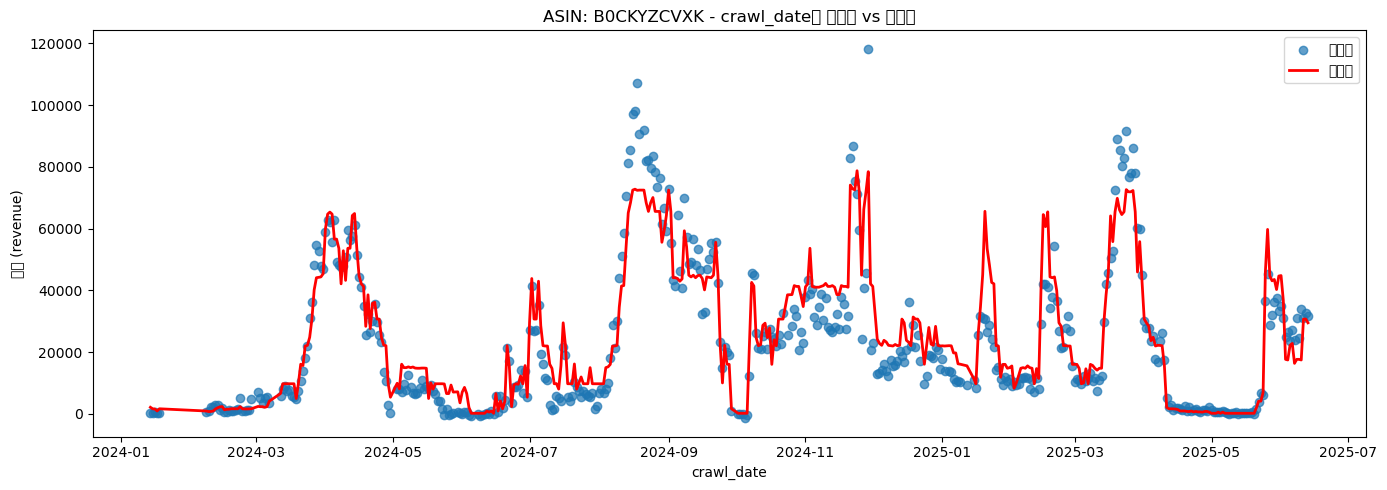

In [141]:

# 2. 매출 합 기준 asin top 5 추출
top5_asin = df.groupby('asin')['revenue'].sum().nlargest(5).index.tolist()

# 3. asin별 반복
for asin in top5_asin:
    df_sub = df[df['asin'] == asin].copy()
    df_sub['crawl_date'] = pd.to_datetime(df_sub['crawl_date'])
    df_sub = df_sub.sort_values('crawl_date')

    # X, y 추출
    X_sub = df_sub[X_cols]
    y_sub = df_sub[y_col]
    
    # RandomForest 모델은 전체 데이터로 미리 학습되어 있다고 가정 (rf)
    y_pred_sub = rf.predict(X_sub)
    
    # 그래프
    plt.figure(figsize=(14,5))
    plt.scatter(df_sub['crawl_date'], y_sub, label='실제값', alpha=0.7)
    plt.plot(df_sub['crawl_date'], y_pred_sub, label='예측값', color='red', linewidth=2)
    plt.xlabel('crawl_date')
    plt.ylabel('매출 (revenue)')
    plt.title(f'ASIN: {asin} - crawl_date별 실제값 vs 예측값')
    plt.legend()
    plt.tight_layout()
    plt.show()